## Creating a GeoDataFrame from scratch
##### Input Geometries

In [1]:
from shapely import Point, Polygon, LineString, MultiPoint, MultiLineString, MultiPolygon, GeometryCollection

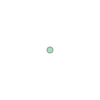

In [2]:
point = Point(0,0)
point

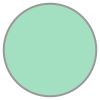

In [3]:
circle = Point(1,1).buffer(0.5)  # Create a circle with radius 0.5 around the point (1,1)
circle

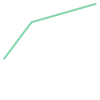

In [4]:
line = LineString([(2,2), (3.5,4), (7,5)])  # Create a line connecting the points (2,2), (3.5,4), and (7,5)
line

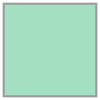

In [5]:
square = Polygon([(3,0), (3,1), (4,1), (4,0)])  # Create a square with corners at (3,0), (3,1), (4,1), and (4,0)
square

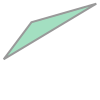

In [6]:
triangle = LineString([(2,2+1.5), (3.5,4+1.5), (7,5+1.5)]).convex_hull
triangle

##### Create a GeoDataFrame

In [7]:
geo_data = { "point": point,
              "circle": circle,
              "line": line,
              "square": square,
              "triangle": triangle }

geo_data

{'point': <POINT (0 0)>,
 'circle': <POLYGON ((1.5 1, 1.498 0.951, 1.49 0.902, 1.478 0.855, 1.462 0.809, 1.441 0...>,
 'line': <LINESTRING (2 2, 3.5 4, 7 5)>,
 'square': <POLYGON ((3 0, 3 1, 4 1, 4 0, 3 0))>,
 'triangle': <POLYGON ((2 3.5, 3.5 5.5, 7 6.5, 2 3.5))>}

In [8]:
import geopandas as gpd

In [9]:
gdf = gpd.GeoDataFrame(geo_data.items(), columns=["geo_name", "geometry"])
gdf

,geo_name,geometry
0,point,POINT (0 0)
1,circle,"POLYGON ((1.5 1, 1.49759 0.95099, 1.49039 0.90..."
2,line,"LINESTRING (2 2, 3.5 4, 7 5)"
3,square,"POLYGON ((3 0, 3 1, 4 1, 4 0, 3 0))"
4,triangle,"POLYGON ((2 3.5, 3.5 5.5, 7 6.5, 2 3.5))"


In [10]:
type(gdf)

geopandas.geodataframe.GeoDataFrame

##### Simple Functions and Computations

In [11]:
gdf

,geo_name,geometry
0,point,POINT (0 0)
1,circle,"POLYGON ((1.5 1, 1.49759 0.95099, 1.49039 0.90..."
2,line,"LINESTRING (2 2, 3.5 4, 7 5)"
3,square,"POLYGON ((3 0, 3 1, 4 1, 4 0, 3 0))"
4,triangle,"POLYGON ((2 3.5, 3.5 5.5, 7 6.5, 2 3.5))"


In [12]:
gdf['geometry_type'] = gdf['geometry'].apply(lambda x: type(x).__name__)  # Add a new column to the GeoDataFrame that contains the type of each geometry
gdf

,geo_name,geometry,geometry_type
0,point,POINT (0 0),Point
1,circle,"POLYGON ((1.5 1, 1.49759 0.95099, 1.49039 0.90...",Polygon
2,line,"LINESTRING (2 2, 3.5 4, 7 5)",LineString
3,square,"POLYGON ((3 0, 3 1, 4 1, 4 0, 3 0))",Polygon
4,triangle,"POLYGON ((2 3.5, 3.5 5.5, 7 6.5, 2 3.5))",Polygon


In [13]:
gdf['geometry_buffer'] = gdf['geometry'].apply(lambda x: x.buffer(0.5))  # Add a new column to the GeoDataFrame that contains a buffer of 0.5 around each geometry
gdf

,geo_name,geometry,geometry_type,geometry_buffer
0,point,POINT (0 0),Point,"POLYGON ((0.5 0, 0.49759 -0.04901, 0.49039 -0...."
1,circle,"POLYGON ((1.5 1, 1.49759 0.95099, 1.49039 0.90...",Polygon,"POLYGON ((1.9994 1.02453, 1.9994 0.97547, 1.99..."
2,line,"LINESTRING (2 2, 3.5 4, 7 5)",LineString,"POLYGON ((3.1 4.3, 3.12949 4.33574, 3.16217 4...."
3,square,"POLYGON ((3 0, 3 1, 4 1, 4 0, 3 0))",Polygon,"POLYGON ((3 -0.5, 2.95099 -0.49759, 2.90245 -0..."
4,triangle,"POLYGON ((2 3.5, 3.5 5.5, 7 6.5, 2 3.5))",Polygon,"POLYGON ((2.25725 3.07125, 2.21389 3.04806, 2...."


In [14]:
gdf['geometry_length'] = gdf['geometry'].apply(lambda x: x.length).tolist()  # Add a new column to the GeoDataFrame that contains the length of each geometry
gdf['geometry_area'] = gdf['geometry'].apply(lambda x: x.area).tolist()  # Add a new column to the GeoDataFrame that contains the area of each geometry
gdf

,geo_name,geometry,geometry_type,geometry_buffer,geometry_length,geometry_area
0,point,POINT (0 0),Point,"POLYGON ((0.5 0, 0.49759 -0.04901, 0.49039 -0....",0.000000,0.000000
1,circle,"POLYGON ((1.5 1, 1.49759 0.95099, 1.49039 0.90...",Polygon,"POLYGON ((1.9994 1.02453, 1.9994 0.97547, 1.99...",3.140331,0.784137
2,line,"LINESTRING (2 2, 3.5 4, 7 5)",LineString,"POLYGON ((3.1 4.3, 3.12949 4.33574, 3.16217 4....",6.140055,0.000000
3,square,"POLYGON ((3 0, 3 1, 4 1, 4 0, 3 0))",Polygon,"POLYGON ((3 -0.5, 2.95099 -0.49759, 2.90245 -0...",4.000000,1.000000
4,triangle,"POLYGON ((2 3.5, 3.5 5.5, 7 6.5, 2 3.5))",Polygon,"POLYGON ((2.25725 3.07125, 2.21389 3.04806, 2....",11.971007,2.750000


#### Visualizing synthetic data with GeoPandas

<Axes: >

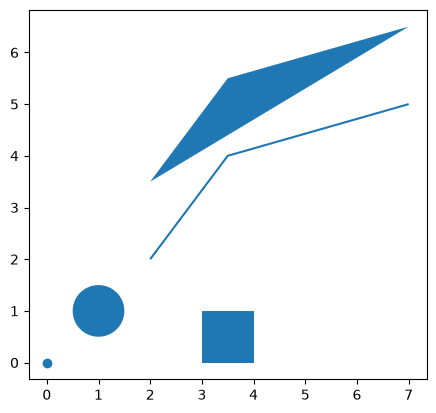

In [16]:
gdf.plot()

In [17]:
import matplotlib.pyplot as plt

<Axes: >

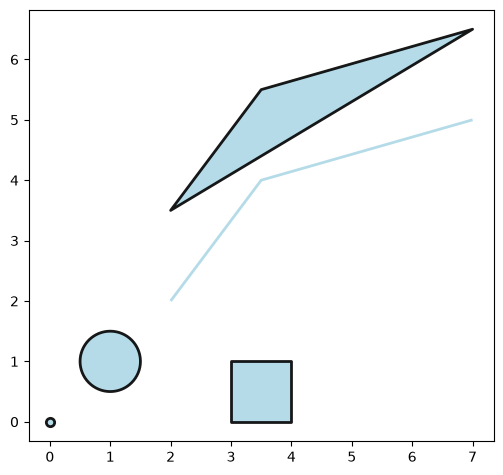

In [25]:
f, ax = plt.subplots(1,1,figsize=(6,6))

gdf.plot(ax=ax, 
         color='lightblue', 
         edgecolor='black',
         linewidth=2,
         alpha=0.9)

<Axes: >

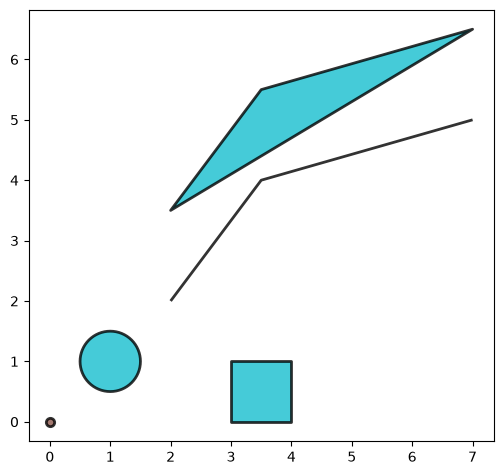

In [26]:
f, ax = plt.subplots(1,1,figsize=(6,6))

gdf.plot(ax=ax,
         column='geometry_type',  # Color the geometries based on their type
         edgecolor='black',
         linewidth=2,
         alpha=0.8)


<Axes: >

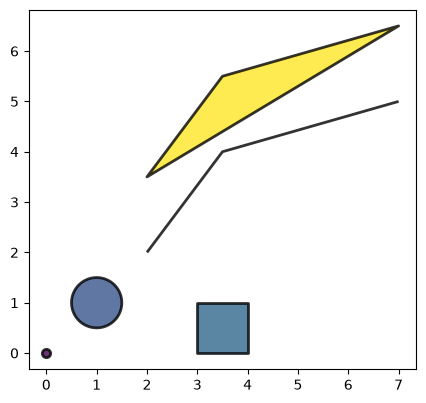

In [31]:
f, ax = plt.subplots(1,1,figsize=(5,5))

gdf.plot(ax=ax,
         column='geometry_length',
         cmap='viridis',  # Use the 'viridis' colormap to color the geometries based on their length
         edgecolor='black',
         linewidth=2,
         alpha=0.8)

#### Visualizing sample data with GeoPandas

In [35]:
import geopandas as gpd
import geodatasets
from geodatasets import get_path

In [38]:
nybb = gpd.read_file(get_path('nybb')) # Load the New York boroughs dataset from GeoPandas
nybb

,BoroCode,BoroName,Shape_Leng,Shape_Area,geometry
0,5,Staten Island,330470.010332,1.623820e+09,"MULTIPOLYGON (((970217.022 145643.332, 970227...."
1,4,Queens,896344.047763,3.045213e+09,"MULTIPOLYGON (((1029606.077 156073.814, 102957..."
2,3,Brooklyn,741080.523166,1.937479e+09,"MULTIPOLYGON (((1021176.479 151374.797, 102100..."
3,1,Manhattan,359299.096471,6.364715e+08,"MULTIPOLYGON (((981219.056 188655.316, 980940...."
4,2,Bronx,464392.991824,1.186925e+09,"MULTIPOLYGON (((1012821.806 229228.265, 101278..."


In [39]:
import matplotlib.pyplot as plt

<Axes: >

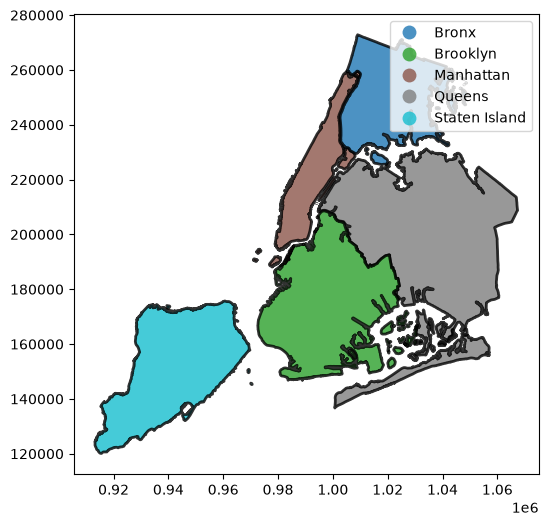

In [41]:
f, ax = plt.subplots(1,1,figsize=(6,6))

nybb.plot(ax=ax, column ='BoroName', linewidth=2, cmap = 'tab10', edgecolor='black', alpha=0.8, legend=True)

(np.float64(905464.7390380859),
 np.float64(1075092.8783935546),
 np.float64(112485.76063504723),
 np.float64(280480.4142594267))

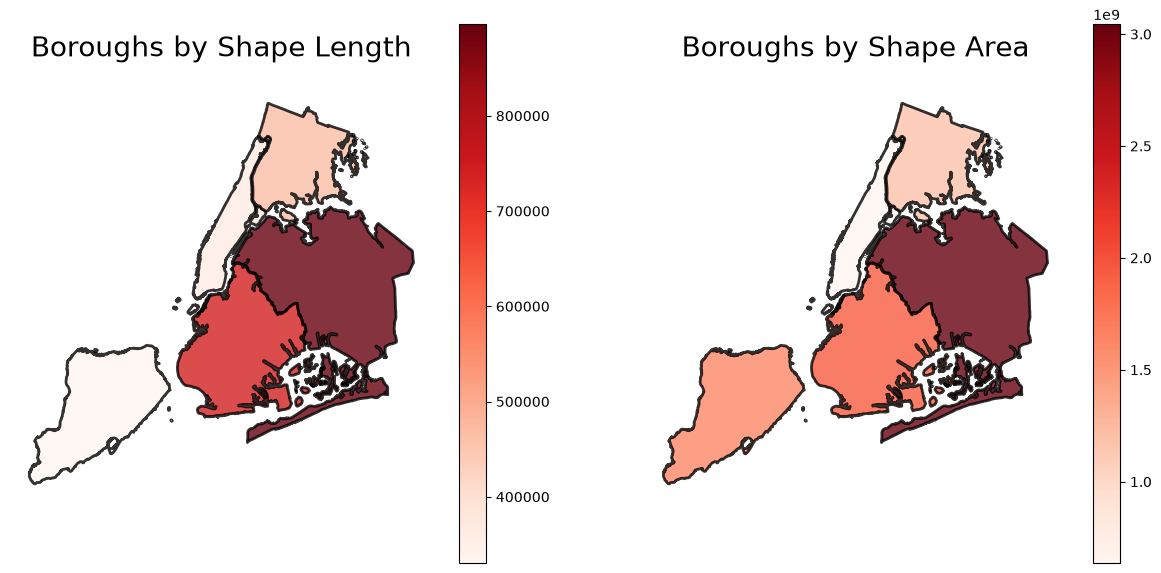

In [45]:
f, ax = plt.subplots(1,2,figsize=(15,7))

nybb.plot(column='Shape_Leng', ax=ax[0], cmap='Reds', edgecolor='black', linewidth=2, alpha=0.8, legend=True)
nybb.plot(column='Shape_Area', ax=ax[1], cmap='Reds', edgecolor='black', linewidth=2, alpha=0.8, legend=True)

ax[0].set_title('Boroughs by Shape Length', fontsize=20, pad=20)
ax[1].set_title('Boroughs by Shape Area', fontsize=20, pad=20)

ax[0].axis('off')
ax[1].axis('off')

* The final visualization shows that the larger a borough is in area, the longer its boundary (perimeter) tends to be. This is why the two maps, colored by area and perimeter, look quite similar. 
* The different shades of red also reveal variations in the spread of these values across boroughs. 
* This simple but important insight helps in understanding how spatial attributes like size and boundary length relate, which is a key step in extracting meaningful geospatial insights from data.